In [1]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [2]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [3]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [4]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  sum_jumps = sum(jumps)
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  cols.append(len(list(set(jumps))))
  cols.append(int(any([b == sum_jumps for b in bolillas_int])))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff", "hjsum"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String,
    "jdiff": pl.String,
    "jsum": pl.String,
    "hjsum": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')
dfRows.select([
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra', 'id', 
    'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 
    'j1', 'j2', 'j3', 'j4', 'j5'
]).rename({
    "j1": "gap_b1_b2",
    "j2": "gap_b2_b3",
    "j3": "gap_b3_b4",
    "j4": "gap_b4_b5",
    "j5": "gap_b5_b6"
}).write_csv('dfrows_tnk.parquet.csv')

TOTAL_LINES=2610


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""26/08/2026""","""1328""","""52 22 01 44 14 35""","""53""","""11 49 36 09 31""","""Promoción Sí o Sí""","""011422354452""","[1, 14, … 52]",1,14,22,35,44,52,"""01""","""14""","""22""","""35""","""44""","""52""",null,null,null,null,null,null,false,0,"""13_08_13_09_08""",31,"""0""","""4""","""2""","""13""","""8""","""13""","""9""","""8""","""51""","""2""","""3""","""0"""
"""23/08/2026""","""1327""","""26 14 10 42 48 11""","""03""","""35 45 12""","""Promoción Sí o Sí""","""101114264248""","[10, 11, … 48]",10,11,14,26,42,48,"""10""","""11""","""14""","""26""","""42""","""48""","""01""","""14""","""22""","""35""","""44""","""52""",true,16,"""01_03_12_16_06""",3,"""1""","""5""","""1""","""1""","""3""","""12""","""16""","""6""","""38""","""2""","""5""","""0"""
"""19/08/2026""","""1326""","""12 09 32 51 14 43""","""35""","""36 29""","""Promoción Sí o Sí""","""091214324351""","[9, 12, … 51]",9,12,14,32,43,51,"""09""","""12""","""14""","""32""","""43""","""51""","""10""","""11""","""14""","""26""","""42""","""48""",false,0,"""03_02_18_11_08""",67,"""1""","""3""","""3""","""3""","""2""","""18""","""11""","""8""","""42""","""2""","""5""","""0"""
"""16/08/2026""","""1325""","""45 32 36 04 43 12""","""39""","""14 17""","""Promoción Sí o Sí""","""041232364345""","[4, 12, … 45]",4,12,32,36,43,45,"""04""","""12""","""32""","""36""","""43""","""45""","""09""","""12""","""14""","""32""","""43""","""51""",false,0,"""08_20_04_07_02""",-74,"""1""","""4""","""2""","""8""","""20""","""4""","""7""","""2""","""41""","""1""","""5""","""0"""
"""12/08/2026""","""1324""","""39 45 27 21 31 11""","""20""","""03 28 35""","""Promoción Sí o Sí""","""112127313945""","[11, 21, … 45]",11,21,27,31,39,45,"""11""","""21""","""27""","""31""","""39""","""45""","""04""","""12""","""32""","""36""","""43""","""45""",true,2,"""10_06_04_08_06""",-16,"""2""","""0""","""6""","""10""","""6""","""4""","""8""","""6""","""34""","""1""","""4""","""0"""
"""09/08/2026""","""1323""","""12 30 26 53 37 29""","""45""","""46 06 09""","""Promoción Sí o Sí""","""122629303753""","[12, 26, … 53]",12,26,29,30,37,53,"""12""","""26""","""29""","""30""","""37""","""53""","""11""","""21""","""27""","""31""","""39""","""45""",false,0,"""14_03_01_07_16""",-4,"""2""","""3""","""3""","""14""","""3""","""1""","""7""","""16""","""41""","""2""","""5""","""0"""
"""05/08/2026""","""1322""","""19 40 07 13 21 50""","""02""","""30 38""","""Promoción Sí o Sí""","""071319214050""","[7, 13, … 50]",7,13,19,21,40,50,"""07""","""13""","""19""","""21""","""40""","""50""","""12""","""26""","""29""","""30""","""37""","""53""",true,8,"""06_06_02_19_10""",-72,"""3""","""2""","""4""","""6""","""6""","""2""","""19""","""10""","""43""","""2""","""4""","""0"""
"""02/08/2026""","""1321""","""05 18 14 52 44 10""","""26""","""20 24""","""Promoción Sí o Sí""","""051014184452""","[5, 10, … 52]",5,10,14,18,44,52,"""05""","""10""","""14""","""18""","""44""","""52""","""07""","""13""","""19""","""21""","""40""","""50""",true,24,"""05_04_04_26_08""",-83,"""1""","""5""","""1""","""5""","""4""","""4""","""26""","""8""","""47""","""1""","""4""","""0"""
"""29/07/2026""","""1320""","""15 13 02 05 18 31""","""45""","""23 37 36""","""Promoción Sí o Sí""","""020513151831""","[2, 5, … 31]",2,5,13,15,18,31,"""02""","""05""","""13""","""15""","""18""","""31""","""05""","""10""","""14""","""18""","""44""","""52""",true,1,"""03_08_02_03_13""",-16,"""4""","""2""","""4""","""3""","""8""","""2""","""3""","""13""","""29""","""1""","""4""","""0"""


In [5]:
dfRows['fecha', 'sorteo', 'bolillas',
    'b1', 'b2', 'b3', 'b4', 'b5', 'b6'].write_json('dfrows_tnk.json')
    
    #.to_json('dfrows_tnk.json', orient='records')

In [6]:
dfRows.filter(
  pl.col("b1") > 10
)

fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""12/08/2026""","""1324""","""39 45 27 21 31 11""","""20""","""03 28 35""","""Promoción Sí o Sí""","""112127313945""","[11, 21, … 45]",11,21,27,31,39,45,"""11""","""21""","""27""","""31""","""39""","""45""","""04""","""12""","""32""","""36""","""43""","""45""",true,2,"""10_06_04_08_06""",-16,"""2""","""0""","""6""","""10""","""6""","""4""","""8""","""6""","""34""","""1""","""4""","""0"""
"""09/08/2026""","""1323""","""12 30 26 53 37 29""","""45""","""46 06 09""","""Promoción Sí o Sí""","""122629303753""","[12, 26, … 53]",12,26,29,30,37,53,"""12""","""26""","""29""","""30""","""37""","""53""","""11""","""21""","""27""","""31""","""39""","""45""",false,0,"""14_03_01_07_16""",-4,"""2""","""3""","""3""","""14""","""3""","""1""","""7""","""16""","""41""","""2""","""5""","""0"""
"""26/07/2026""","""1319""","""17 27 37 46 43 47""","""45""","""48 30 42 13""","""Promoción Sí o Sí""","""172737434647""","[17, 27, … 47]",17,27,37,43,46,47,"""17""","""27""","""37""","""43""","""46""","""47""","""02""","""05""","""13""","""15""","""18""","""31""",true,9,"""10_10_06_03_01""",-5,"""4""","""1""","""5""","""10""","""10""","""6""","""3""","""1""","""30""","""2""","""4""","""0"""
"""22/07/2026""","""1318""","""12 47 13 40 30 53""","""24""","""50 26 41""","""Promoción Sí o Sí""","""121330404753""","[12, 13, … 53]",12,13,30,40,47,53,"""12""","""13""","""30""","""40""","""47""","""53""","""17""","""27""","""37""","""43""","""46""","""47""",false,0,"""01_17_10_07_06""",-29,"""2""","""3""","""3""","""1""","""17""","""10""","""7""","""6""","""41""","""2""","""5""","""0"""
"""12/07/2026""","""1315""","""23 39 32 22 17 53""","""13""","""31 08 49""","""Promoción Sí o Sí""","""172223323953""","[17, 22, … 53]",17,22,23,32,39,53,"""17""","""22""","""23""","""32""","""39""","""53""","""07""","""08""","""10""","""25""","""36""","""51""",false,0,"""05_01_09_07_14""",41,"""2""","""2""","""4""","""5""","""1""","""9""","""7""","""14""","""36""","""1""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10/09/1995""","""0048""","""11 19 20 21 24 36""","""""","""""","""""","""111920212436""","[11, 19, … 36]",11,19,20,21,24,36,"""11""","""19""","""20""","""21""","""24""","""36""","""10""","""13""","""17""","""21""","""23""","""32""",true,8,"""08_01_01_03_12""",10,"""2""","""3""","""3""","""8""","""1""","""1""","""3""","""12""","""25""","""1""","""4""","""0"""
"""23/07/1995""","""0041""","""14 18 21 25 29 30""","""""","""""","""""","""141821252930""","[14, 18, … 30]",14,18,21,25,29,30,"""14""","""18""","""21""","""25""","""29""","""30""","""03""","""04""","""06""","""10""","""16""","""29""",true,8,"""04_03_04_04_01""",1,"""1""","""3""","""3""","""4""","""3""","""4""","""4""","""1""","""16""","""0""","""3""","""0"""
"""09/04/1995""","""0026""","""16 18 24 25 29 31""","""""","""""","""""","""161824252931""","[16, 18, … 31]",16,18,24,25,29,31,"""16""","""18""","""24""","""25""","""29""","""31""","""01""","""03""","""19""","""27""","""30""","""35""",false,0,"""02_06_01_04_02""",-30,"""2""","""3""","""3""","""2""","""6""","""1""","""4""","""2""","""15""","""0""","""4""","""0"""


In [7]:

def count_column (df: pl.DataFrame, col_name: str, k: int = None) -> None:
  df_viz = (df if k == None else df[0:k]) \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

jjsum = count_column(dfRows, 'hjsum', 200)
jdiff_count = count_column(dfRows, 'jdiff', 200)

j1_count = count_column(dfRows, 'j1', 200)
j2_count = count_column(dfRows, 'j2', 200)
j3_count = count_column(dfRows, 'j3', 200)
j4_count = count_column(dfRows, 'j4', 200)
j5_count = count_column(dfRows, 'j5', 200)

joor_count = count_column(dfRows, "joor", 200)
primes_count = count_column(dfRows, 'primes_count', 200)
evens_count = count_column(dfRows, 'evens_count', 200)
odds_count = count_column(dfRows, 'odds_count', 200)

jsums = count_column(dfRows, 'jsum', 200)
# print(jsums[0:22])



:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [8]:
dfRows.item(0, 'b2')

14

In [9]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [10]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='01'
df_viz FOR str_b1 = 01


post_str_b1,count,percent
str,u32,f64
"""01""",59,16.857143
"""02""",45,12.857143
"""05""",32,9.142857
"""03""",30,8.571429
"""04""",24,6.857143
…,…,…
"""21""",2,0.571429
"""28""",1,0.285714
"""24""",1,0.285714


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 01
Last 3 results last_results=['12', '03']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""19/07/2026""","""1317""","""52 20 40 01 02 33""","""12""","""46 25""","""Promoción Sí o Sí""","""010220334052""","[1, 2, … 52]",1,2,20,33,40,52,"""01""","""02""","""20""","""33""","""40""","""52""","""12""","""13""","""30""","""40""","""47""","""53""",false,0,"""01_18_13_07_12""",-9,"""1""","""4""","""2""","""1""","""18""","""13""","""7""","""12""","""51""","""3""","""5""","""0"""
"""21/06/2026""","""1309""","""03 20 01 40 52 23""","""12""","""29 27""","""Promoción Sí o Sí""","""010320234052""","[1, 3, … 52]",1,3,20,23,40,52,"""01""","""03""","""20""","""23""","""40""","""52""","""03""","""12""","""15""","""23""","""24""","""29""",false,0,"""02_17_03_17_12""",-104,"""2""","""3""","""3""","""2""","""17""","""3""","""17""","""12""","""51""","""3""","""4""","""0"""
"""22/04/2026""","""1292""","""22 01 40 52 23 25""","""11""","""20 51 44""","""Promoción Sí o Sí""","""012223254052""","[1, 22, … 52]",1,22,23,25,40,52,"""01""","""22""","""23""","""25""","""40""","""52""","""03""","""11""","""18""","""19""","""20""","""44""",false,0,"""21_01_02_15_12""",-19,"""1""","""3""","""3""","""21""","""1""","""2""","""15""","""12""","""51""","""3""","""5""","""0"""
"""01/04/2026""","""1286""","""25 23 14 42 37 01""","""02""","""10 09""","""Promoción Sí o Sí""","""011423253742""","[1, 14, … 42]",1,14,23,25,37,42,"""01""","""14""","""23""","""25""","""37""","""42""","""10""","""12""","""14""","""35""","""42""","""50""",false,0,"""13_09_02_12_05""",-54,"""2""","""2""","""4""","""13""","""9""","""2""","""12""","""5""","""41""","""2""","""5""","""0"""
"""21/01/2026""","""1266""","""45 27 15 01 31 21""","""44""","""03 41 50 32""","""Promoción Sí o Sí""","""011521273145""","[1, 15, … 45]",1,15,21,27,31,45,"""01""","""15""","""21""","""27""","""31""","""45""","""04""","""08""","""19""","""28""","""35""","""43""",true,10,"""14_06_06_04_14""",24,"""1""","""0""","""6""","""14""","""6""","""6""","""4""","""14""","""44""","""2""","""3""","""0"""
"""18/01/2026""","""1265""","""01 28 31 37 11 09""","""26""","""08 50""","""Promoción Sí o Sí""","""010911283137""","[1, 9, … 37]",1,9,11,28,31,37,"""01""","""09""","""11""","""28""","""31""","""37""","""01""","""15""","""21""","""27""","""31""","""45""",false,0,"""08_02_17_03_06""",96,"""3""","""1""","""5""","""8""","""2""","""17""","""3""","""6""","""36""","""1""","""5""","""0"""
"""30/11/2025""","""1251""","""38 01 32 37 34 50""","""25""","""45 31 09 08 10""","""Promoción Sí o Sí""","""013234373850""","[1, 32, … 50]",1,32,34,37,38,50,"""01""","""32""","""34""","""37""","""38""","""50""","""12""","""25""","""28""","""29""","""33""","""43""",false,0,"""31_02_03_01_12""",49,"""1""","""4""","""2""","""31""","""2""","""3""","""1""","""12""","""49""","""2""","""5""","""0"""
"""10/09/2025""","""1228""","""01 16 06 45 33 38""","""27""","""46 09""","""Promoción Sí o Sí""","""010616333845""","[1, 6, … 45]",1,6,16,33,38,45,"""01""","""06""","""16""","""33""","""38""","""45""","""02""","""06""","""12""","""33""","""35""","""38""",true,16,"""05_10_17_05_07""",54,"""0""","""3""","""3""","""5""","""10""","""17""","""5""","""7""","""44""","""2""","""4""","""0"""
"""30/07/2025""","""1216""","""43 28 03 09 01 25""","""23""","""31""","""Promoción Sí o Sí""","""010309252843""","[1, 3, … 43]",1,3,9,25,28,43,"""01""","""03""","""09""","""25""","""28""","""43""","""02""","""14""","""23""","""41""","""45""","""46""",false,0,"""02_06_16_03_15""",77,"""2""","""1""","""5""","""2""","""6""","""16""","""3""","""15""","""42""","""2""","""5""","""0"""


df_jumps_map FOR str_b1 = 01


jumps_map,count
str,u32
"""01_15_07_16_09""",1
"""18_02_03_05_15""",1
"""04_02_13_13_01""",1
"""02_11_03_09_02""",1
"""16_04_18_03_02""",1
…,…
"""09_03_03_03_23""",1
"""03_20_14_01_07""",1
"""06_04_11_14_01""",1


df_unijump FOR str_b1 = 01


unijump,count
i64,u32
-20,10
1,8
-16,7
11,6
-32,6
…,…
60,1
-27,1
-44,1


In [11]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='14'
df_viz FOR str_b2 = 14


post_str_b2,count,percent
str,u32,f64
"""08""",10,8.130081
"""13""",10,8.130081
"""14""",8,6.504065
"""06""",7,5.691057
"""11""",7,5.691057
…,…,…
"""29""",2,1.626016
"""22""",1,0.813008
"""27""",1,0.813008


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 14
Last 3 results last_results=['13', '24', '12']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""12/04/2026""","""1289""","""42 38 49 14 34 12""","""05""","""35 17 39""","""Promoción Sí o Sí""","""121434384249""","[12, 14, … 49]",12,14,34,38,42,49,"""12""","""14""","""34""","""38""","""42""","""49""","""06""","""24""","""31""","""32""","""46""","""51""",true,8,"""02_20_04_04_07""",-63,"""0""","""5""","""1""","""2""","""20""","""4""","""4""","""7""","""37""","""1""","""4""","""0"""
"""01/04/2026""","""1286""","""25 23 14 42 37 01""","""02""","""10 09""","""Promoción Sí o Sí""","""011423253742""","[1, 14, … 42]",1,14,23,25,37,42,"""01""","""14""","""23""","""25""","""37""","""42""","""10""","""12""","""14""","""35""","""42""","""50""",false,0,"""13_09_02_12_05""",-54,"""2""","""2""","""4""","""13""","""9""","""2""","""12""","""5""","""41""","""2""","""5""","""0"""
"""08/03/2026""","""1279""","""49 21 48 14 24 06""","""18""","""09 02 41""","""Promoción Sí o Sí""","""061421244849""","[6, 14, … 49]",6,14,21,24,48,49,"""06""","""14""","""21""","""24""","""48""","""49""","""06""","""13""","""18""","""32""","""37""","""52""",true,16,"""08_07_03_24_01""",-97,"""0""","""4""","""2""","""8""","""7""","""3""","""24""","""1""","""43""","""1""","""5""","""0"""
"""21/12/2025""","""1257""","""25 27 23 36 14 10""","""38""","""03""","""Promoción Sí o Sí""","""101423252736""","[10, 14, … 36]",10,14,23,25,27,36,"""10""","""14""","""23""","""25""","""27""","""36""","""08""","""13""","""16""","""24""","""31""","""33""",true,8,"""04_09_02_02_09""",-19,"""1""","""3""","""3""","""4""","""9""","""2""","""2""","""9""","""26""","""0""","""3""","""0"""
"""02/11/2025""","""1243""","""35 03 20 14 25 32""","""31""","""12 16""","""Promoción Sí o Sí""","""031420253235""","[3, 14, … 35]",3,14,20,25,32,35,"""03""","""14""","""20""","""25""","""32""","""35""","""14""","""28""","""29""","""34""","""38""","""44""",false,0,"""11_06_05_07_03""",-8,"""1""","""3""","""3""","""11""","""6""","""5""","""7""","""3""","""32""","""1""","""5""","""1"""
"""03/08/2025""","""1217""","""45 41 02 14 23 46""","""22""","""05 39""","""Promoción Sí o Sí""","""021423414546""","[2, 14, … 46]",2,14,23,41,45,46,"""02""","""14""","""23""","""41""","""45""","""46""","""06""","""21""","""23""","""33""","""36""","""38""",false,0,"""12_09_18_04_01""",69,"""3""","""3""","""3""","""12""","""9""","""18""","""4""","""1""","""44""","""2""","""5""","""0"""
"""25/06/2025""","""1206""","""38 30 08 27 48 14""","""17""","""18""","""Promoción Sí o Sí""","""081427303848""","[8, 14, … 48]",8,14,27,30,38,48,"""08""","""14""","""27""","""30""","""38""","""48""","""22""","""23""","""24""","""32""","""37""","""47""",false,0,"""06_13_03_08_10""",-50,"""0""","""5""","""1""","""6""","""13""","""3""","""8""","""10""","""40""","""2""","""5""","""0"""
"""01/06/2025""","""1199""","""02 16 19 14 43 22""","""04""","""17 48 27""","""Promoción Sí o Sí""","""021416192243""","[2, 14, … 43]",2,14,16,19,22,43,"""02""","""14""","""16""","""19""","""22""","""43""","""01""","""05""","""21""","""30""","""36""","""50""",true,8,"""12_02_03_03_21""",31,"""3""","""4""","""2""","""12""","""2""","""3""","""3""","""21""","""41""","""2""","""4""","""0"""
"""16/04/2025""","""1186""","""14 31 46 38 48 12""","""15""","""39 30""","""Promoción Sí o Sí""","""121431384648""","[12, 14, … 48]",12,14,31,38,46,48,"""12""","""14""","""31""","""38""","""46""","""48""","""02""","""06""","""11""","""33""","""34""","""42""",false,0,"""02_17_07_08_02""",-54,"""1""","""5""","""1""","""2""","""17""","""7""","""8""","""2""","""36""","""1""","""4""","""0"""


df_jumps_map FOR str_b2 = 14


jumps_map,count
str,u32
"""12_09_18_04_01""",1
"""11_03_04_15_04""",1
"""09_06_05_07_11""",1
"""01_17_04_07_03""",1
"""02_02_17_08_01""",1
…,…
"""05_06_02_08_05""",1
"""04_04_02_04_10""",1
"""11_10_02_10_05""",1


df_unijump FOR str_b2 = 14


unijump,count
i64,u32
-23,4
4,4
-49,3
7,3
-16,3
…,…
36,1
-15,1
-59,1


In [12]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='22'
df_viz FOR str_b3 = 22


post_str_b3,count,percent
str,u32,f64
"""19""",7,7.142857
"""18""",6,6.122449
"""17""",6,6.122449
"""26""",5,5.102041
"""16""",5,5.102041
…,…,…
"""36""",2,2.040816
"""09""",2,2.040816
"""14""",1,1.020408


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 22
Last 3 results last_results=['21', '13', '26']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""01/07/2026""","""1312""","""06 36 22 03 47 24""","""25""","""05 08 40 27""","""Promoción Sí o Sí""","""030622243647""","[3, 6, … 47]",3,6,22,24,36,47,"""03""","""06""","""22""","""24""","""36""","""47""","""02""","""11""","""13""","""37""","""46""","""49""",true,16,"""03_16_02_12_11""",-86,"""2""","""4""","""2""","""3""","""16""","""2""","""12""","""11""","""44""","""3""","""5""","""0"""
"""04/03/2026""","""1278""","""21 28 36 22 24 16""","""41""","""49 32""","""Promoción Sí o Sí""","""162122242836""","[16, 21, … 36]",16,21,22,24,28,36,"""16""","""21""","""22""","""24""","""28""","""36""","""06""","""14""","""21""","""24""","""48""","""49""",false,0,"""05_01_02_04_08""",5,"""0""","""5""","""1""","""5""","""1""","""2""","""4""","""8""","""20""","""0""","""5""","""0"""
"""18/02/2026""","""1274""","""02 32 42 33 07 22""","""30""","""01 19 09""","""Promoción Sí o Sí""","""020722323342""","[2, 7, … 42]",2,7,22,32,33,42,"""02""","""07""","""22""","""32""","""33""","""42""","""23""","""24""","""26""","""43""","""46""","""49""",true,16,"""05_15_10_01_09""",10,"""2""","""4""","""2""","""5""","""15""","""10""","""1""","""9""","""40""","""2""","""5""","""0"""
"""15/02/2026""","""1273""","""22 05 40 24 41 09""","""04""","""44 07 36""","""Promoción Sí o Sí""","""050922244041""","[5, 9, … 41]",5,9,22,24,40,41,"""05""","""09""","""22""","""24""","""40""","""41""","""02""","""07""","""22""","""32""","""33""","""42""",true,16,"""04_13_02_16_01""",-99,"""2""","""3""","""3""","""4""","""13""","""2""","""16""","""1""","""36""","""2""","""5""","""0"""
"""05/01/2025""","""1157""","""18 49 45 13 35 22""","""21""","""19 07 36 08""","""Promoción Sí o Sí""","""131822354549""","[13, 18, … 49]",13,18,22,35,45,49,"""13""","""18""","""22""","""35""","""45""","""49""","""20""","""24""","""25""","""40""","""44""","""47""",false,0,"""05_04_13_10_04""",31,"""1""","""2""","""4""","""5""","""4""","""13""","""10""","""4""","""36""","""2""","""4""","""0"""
"""31/07/2024""","""1112""","""37 07 28 12 22 29""","""43""","""01 40 36 25""","""Promoción Sí o Sí""","""071222282937""","[7, 12, … 37]",7,12,22,28,29,37,"""07""","""12""","""22""","""28""","""29""","""37""","""02""","""17""","""36""","""38""","""41""","""43""",false,0,"""05_10_06_01_08""",5,"""3""","""3""","""3""","""5""","""10""","""6""","""1""","""8""","""30""","""1""","""5""","""0"""
"""06/03/2024""","""1070""","""30 22 04 07 39 37""","""38""","""43 02 18""","""Promoción Sí o Sí""","""040722303739""","[4, 7, … 39]",4,7,22,30,37,39,"""04""","""07""","""22""","""30""","""37""","""39""","""12""","""18""","""30""","""32""","""34""","""35""",true,16,"""03_15_08_07_02""",-35,"""2""","""3""","""3""","""3""","""15""","""8""","""7""","""2""","""35""","""1""","""5""","""0"""
"""25/10/2023""","""1032""","""38 17 22 26 21 36""","""07""","""27 29 11""","""Promoción Sí o Sí""","""172122263638""","[17, 21, … 38]",17,21,22,26,36,38,"""17""","""21""","""22""","""26""","""36""","""38""","""06""","""10""","""11""","""19""","""36""","""39""",false,0,"""04_01_04_10_02""",-14,"""1""","""4""","""2""","""4""","""1""","""4""","""10""","""2""","""21""","""1""","""4""","""1"""
"""12/04/2023""","""0976""","""22 25 38 08 33 06""","""12""","""20""","""Promoción Sí o Sí""","""060822253338""","[6, 8, … 38]",6,8,22,25,33,38,"""06""","""08""","""22""","""25""","""33""","""38""","""04""","""13""","""15""","""20""","""40""","""46""",true,16,"""02_14_03_08_05""",-63,"""0""","""4""","""2""","""2""","""14""","""3""","""8""","""5""","""32""","""1""","""5""","""0"""


df_jumps_map FOR str_b3 = 22


jumps_map,count
str,u32
"""08_09_04_04_07""",1
"""01_11_05_10_05""",1
"""10_06_06_03_10""",1
"""08_12_16_02_02""",1
"""04_08_08_05_09""",1
…,…
"""03_06_08_07_04""",1
"""01_13_09_01_03""",1
"""04_13_02_16_01""",1


df_unijump FOR str_b3 = 22


unijump,count
i64,u32
5,3
-27,3
-42,3
8,3
-10,2
…,…
18,1
-22,1
-48,1


In [13]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='35'
df_viz FOR str_b4 = 35


post_str_b4,count,percent
str,u32,f64
"""26""",7,8.641975
"""20""",5,6.17284
"""17""",4,4.938272
"""32""",4,4.938272
"""24""",4,4.938272
…,…,…
"""13""",1,1.234568
"""21""",1,1.234568
"""43""",1,1.234568


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 35
Last 3 results last_results=['17', '20']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""05/04/2026""","""1287""","""10 50 42 14 35 12""","""47""","""33 01 44""","""Promoción Sí o Sí""","""101214354250""","[10, 12, … 50]",10,12,14,35,42,50,"""10""","""12""","""14""","""35""","""42""","""50""","""04""","""11""","""14""","""20""","""28""","""46""",true,8,"""02_02_21_07_08""",100,"""0""","""5""","""1""","""2""","""2""","""21""","""7""","""8""","""40""","""1""","""4""","""0"""
"""18/03/2026""","""1282""","""16 27 37 48 35 15""","""02""","""33 08""","""Promoción Sí o Sí""","""151627353748""","[15, 16, … 48]",15,16,27,35,37,48,"""15""","""16""","""27""","""35""","""37""","""48""","""07""","""09""","""14""","""17""","""44""","""46""",false,0,"""01_11_08_02_11""",8,"""1""","""2""","""4""","""1""","""11""","""8""","""2""","""11""","""33""","""2""","""4""","""0"""
"""11/01/2026""","""1263""","""38 28 17 40 35 05""","""11""","""49 19""","""Promoción Sí o Sí""","""051728353840""","[5, 17, … 40]",5,17,28,35,38,40,"""05""","""17""","""28""","""35""","""38""","""40""","""07""","""12""","""18""","""20""","""33""","""42""",false,0,"""12_11_07_03_02""",0,"""2""","""3""","""3""","""12""","""11""","""7""","""3""","""2""","""35""","""2""","""5""","""1"""
"""14/12/2025""","""1255""","""19 37 50 27 35 14""","""39""","""08""","""Promoción Sí o Sí""","""141927353750""","[14, 19, … 50]",14,19,27,35,37,50,"""14""","""19""","""27""","""35""","""37""","""50""","""10""","""12""","""13""","""14""","""25""","""39""",true,8,"""05_08_08_02_13""",26,"""2""","""2""","""4""","""5""","""8""","""8""","""2""","""13""","""36""","""1""","""4""","""0"""
"""09/04/2025""","""1184""","""35 24 49 01 12 39""","""21""","""13 07 26""","""Promoción Sí o Sí""","""011224353949""","[1, 12, … 49]",1,12,24,35,39,49,"""01""","""12""","""24""","""35""","""39""","""49""","""22""","""36""","""39""","""44""","""46""","""48""",false,0,"""11_12_11_04_10""",23,"""0""","""2""","""4""","""11""","""12""","""11""","""4""","""10""","""48""","""4""","""4""","""0"""
"""26/03/2025""","""1180""","""43 01 05 37 35 13""","""39""","""38 07 45 16""","""Promoción Sí o Sí""","""010513353743""","[1, 5, … 43]",1,5,13,35,37,43,"""01""","""05""","""13""","""35""","""37""","""43""","""25""","""28""","""29""","""31""","""46""","""47""",true,19,"""04_08_22_02_06""",102,"""4""","""0""","""6""","""4""","""8""","""22""","""2""","""6""","""42""","""1""","""5""","""0"""
"""05/01/2025""","""1157""","""18 49 45 13 35 22""","""21""","""19 07 36 08""","""Promoción Sí o Sí""","""131822354549""","[13, 18, … 49]",13,18,22,35,45,49,"""13""","""18""","""22""","""35""","""45""","""49""","""20""","""24""","""25""","""40""","""44""","""47""",false,0,"""05_04_13_10_04""",31,"""1""","""2""","""4""","""5""","""4""","""13""","""10""","""4""","""36""","""2""","""4""","""0"""
"""29/09/2024""","""1129""","""43 47 26 35 15 12""","""45""","""08 04 06""","""Promoción Sí o Sí""","""121526354347""","[12, 15, … 47]",12,15,26,35,43,47,"""12""","""15""","""26""","""35""","""43""","""47""","""13""","""17""","""20""","""43""","""47""","""50""",false,0,"""03_11_09_08_04""",-15,"""2""","""2""","""4""","""3""","""11""","""9""","""8""","""4""","""35""","""1""","""5""","""1"""
"""23/06/2024""","""1101""","""30 41 11 05 36 35""","""15""","""44 26""","""Promoción Sí o Sí""","""051130353641""","[5, 11, … 41]",5,11,30,35,36,41,"""05""","""11""","""30""","""35""","""36""","""41""","""01""","""06""","""09""","""11""","""14""","""43""",true,16,"""06_19_05_01_05""",-39,"""3""","""2""","""4""","""6""","""19""","""5""","""1""","""5""","""36""","""1""","""4""","""1""

df_jumps_map FOR str_b4 = 35


jumps_map,count
str,u32
"""01_17_04_07_03""",1
"""01_06_17_09_01""",1
"""17_01_12_01_03""",1
"""05_11_08_03_06""",1
"""05_04_13_10_04""",1
…,…
"""03_16_14_07_03""",1
"""20_10_04_01_03""",1
"""12_01_16_01_07""",1


df_unijump FOR str_b4 = 35


unijump,count
i64,u32
-46,3
3,3
73,2
23,2
134,2
…,…
26,1
9,1
-42,1


In [14]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='44'
df_viz FOR str_b5 = 44


post_str_b5,count,percent
str,u32,f64
"""36""",6,11.111111
"""32""",5,9.259259
"""41""",4,7.407407
"""43""",4,7.407407
"""31""",4,7.407407
…,…,…
"""14""",1,1.851852
"""46""",1,1.851852
"""20""",1,1.851852


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 44
Last 3 results last_results=['40', '23', '31']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""02/08/2026""","""1321""","""05 18 14 52 44 10""","""26""","""20 24""","""Promoción Sí o Sí""","""051014184452""","[5, 10, … 52]",5,10,14,18,44,52,"""05""","""10""","""14""","""18""","""44""","""52""","""07""","""13""","""19""","""21""","""40""","""50""",true,24,"""05_04_04_26_08""",-83,"""1""","""5""","""1""","""5""","""4""","""4""","""26""","""8""","""47""","""1""","""4""","""0"""
"""20/05/2026""","""1300""","""45 19 20 05 41 44""","""14""","""39 24 50""","""Promoción Sí o Sí""","""051920414445""","[5, 19, … 45]",5,19,20,41,44,45,"""05""","""19""","""20""","""41""","""44""","""45""","""06""","""10""","""16""","""19""","""31""","""47""",true,16,"""14_01_21_03_01""",125,"""3""","""2""","""4""","""14""","""1""","""21""","""3""","""1""","""40""","""2""","""4""","""0"""
"""22/03/2026""","""1283""","""07 17 14 46 09 44""","""34""","""10 06 31 02""","""Promoción Sí o Sí""","""070914174446""","[7, 9, … 46]",7,9,14,17,44,46,"""07""","""09""","""14""","""17""","""44""","""46""","""08""","""11""","""12""","""14""","""23""","""25""",true,16,"""02_05_03_27_02""",-106,"""2""","""3""","""3""","""2""","""5""","""3""","""27""","""2""","""39""","""1""","""4""","""0"""
"""31/12/2025""","""1260""","""38 35 44 47 37 28""","""45""","""03 49""","""Promoción Sí o Sí""","""283537384447""","[28, 35, … 47]",28,35,37,38,44,47,"""28""","""35""","""37""","""38""","""44""","""47""","""21""","""23""","""26""","""39""","""48""","""49""",true,16,"""07_02_01_06_03""",-16,"""2""","""3""","""3""","""7""","""2""","""1""","""6""","""3""","""19""","""0""","""5""","""0"""
"""16/11/2025""","""1247""","""15 04 46 41 44 10""","""03""","""18 31 13""","""Promoción Sí o Sí""","""041015414446""","[4, 10, … 46]",4,10,15,41,44,46,"""04""","""10""","""15""","""41""","""44""","""46""","""02""","""21""","""28""","""33""","""40""","""44""",true,16,"""06_05_26_03_02""",132,"""1""","""4""","""2""","""6""","""5""","""26""","""3""","""2""","""42""","""1""","""5""","""0"""
"""21/09/2025""","""1231""","""46 44 02 28 20 32""","""39""","""""","""""","""022028324446""","[2, 20, … 46]",2,20,28,32,44,46,"""02""","""20""","""28""","""32""","""44""","""46""","""21""","""24""","""31""","""39""","""43""","""46""",true,20,"""18_08_04_12_02""",-36,"""1""","""6""","""0""","""18""","""8""","""4""","""12""","""2""","""44""","""2""","""5""","""1"""
"""02/03/2025""","""1173""","""39 09 28 46 18 44""","""15""","""30 04 14""","""Promoción Sí o Sí""","""091828394446""","[9, 18, … 46]",9,18,28,39,44,46,"""09""","""18""","""28""","""39""","""44""","""46""","""01""","""03""","""12""","""28""","""32""","""47""",false,0,"""09_10_11_05_02""",17,"""0""","""4""","""2""","""9""","""10""","""11""","""5""","""2""","""37""","""2""","""5""","""0"""
"""19/02/2025""","""1170""","""44 02 19 47 29 31""","""21""","""32 14 35""","""Promoción Sí o Sí""","""021929314447""","[2, 19, … 47]",2,19,29,31,44,47,"""02""","""19""","""29""","""31""","""44""","""47""","""05""","""08""","""10""","""30""","""36""","""44""",true,1,"""17_10_02_13_03""",-60,"""5""","""2""","""4""","""17""","""10""","""2""","""13""","""3""","""45""","""3""","""5""","""0"""
"""19/01/2025""","""1161""","""23 44 45 05 02 01""","""16""","""24 19""","""Promoción Sí o Sí""","""010205234445""","[1, 2, … 45]",1,2,5,23,44,45,"""01""","""02""","""05""","""23""","""44""","""45""","""06""","""10""","""21""","""31""","""32""","""49""",false,0,"""01_03_18_21_01""",14,"""3""","""2""","""4""","""1""","""3""","""18""","""21""","""1""","""44""","""2""","""4""","""1"""


df_jumps_map FOR str_b5 = 44


jumps_map,count
str,u32
"""07_10_09_05_01""",1
"""03_01_21_16_01""",1
"""05_02_04_30_01""",1
"""02_05_03_27_02""",1
"""17_10_02_13_03""",1
…,…
"""01_09_12_20_01""",1
"""02_07_03_24_01""",1
"""18_02_12_09_01""",1


df_unijump FOR str_b5 = 44


unijump,count
i64,u32
72,2
-61,2
1,2
-1,2
64,1
…,…
132,1
11,1
-2,1


In [15]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='52'
df_viz FOR str_b6 = 52


post_str_blast,count,percent
str,u32,f64
"""29""",2,33.333333
"""45""",1,16.666667
"""44""",1,16.666667
"""50""",1,16.666667
"""53""",1,16.666667


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 52
Last 3 results last_results=['50', '53', '29']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""02/08/2026""","""1321""","""05 18 14 52 44 10""","""26""","""20 24""","""Promoción Sí o Sí""","""051014184452""","[5, 10, … 52]",5,10,14,18,44,52,"""05""","""10""","""14""","""18""","""44""","""52""","""07""","""13""","""19""","""21""","""40""","""50""",true,24,"""05_04_04_26_08""",-83,"""1""","""5""","""1""","""5""","""4""","""4""","""26""","""8""","""47""","""1""","""4""","""0"""
"""19/07/2026""","""1317""","""52 20 40 01 02 33""","""12""","""46 25""","""Promoción Sí o Sí""","""010220334052""","[1, 2, … 52]",1,2,20,33,40,52,"""01""","""02""","""20""","""33""","""40""","""52""","""12""","""13""","""30""","""40""","""47""","""53""",false,0,"""01_18_13_07_12""",-9,"""1""","""4""","""2""","""1""","""18""","""13""","""7""","""12""","""51""","""3""","""5""","""0"""
"""21/06/2026""","""1309""","""03 20 01 40 52 23""","""12""","""29 27""","""Promoción Sí o Sí""","""010320234052""","[1, 3, … 52]",1,3,20,23,40,52,"""01""","""03""","""20""","""23""","""40""","""52""","""03""","""12""","""15""","""23""","""24""","""29""",false,0,"""02_17_03_17_12""",-104,"""2""","""3""","""3""","""2""","""17""","""3""","""17""","""12""","""51""","""3""","""4""","""0"""
"""17/05/2026""","""1299""","""41 31 29 52 10 12""","""43""","""46 48 20 40""","""Promoción Sí o Sí""","""101229314152""","[10, 12, … 52]",10,12,29,31,41,52,"""10""","""12""","""29""","""31""","""41""","""52""","""05""","""19""","""20""","""41""","""44""","""45""",false,0,"""02_17_02_10_11""",-83,"""3""","""3""","""3""","""2""","""17""","""2""","""10""","""11""","""42""","""3""","""4""","""0"""
"""22/04/2026""","""1292""","""22 01 40 52 23 25""","""11""","""20 51 44""","""Promoción Sí o Sí""","""012223254052""","[1, 22, … 52]",1,22,23,25,40,52,"""01""","""22""","""23""","""25""","""40""","""52""","""03""","""11""","""18""","""19""","""20""","""44""",false,0,"""21_01_02_15_12""",-19,"""1""","""3""","""3""","""21""","""1""","""2""","""15""","""12""","""51""","""3""","""5""","""0"""
"""11/03/2026""","""1280""","""52 37 32 13 18 06""","""50""","""42 15""","""Promoción Sí o Sí""","""061318323752""","[6, 13, … 52]",6,13,18,32,37,52,"""06""","""13""","""18""","""32""","""37""","""52""","""03""","""04""","""07""","""08""","""19""","""29""",false,0,"""07_05_14_05_15""",66,"""2""","""4""","""2""","""7""","""5""","""14""","""5""","""15""","""46""","""2""","""4""","""0"""


df_jumps_map FOR str_b6 = 52


jumps_map,count
str,u32
"""05_04_04_26_08""",1
"""01_18_13_07_12""",1
"""21_01_02_15_12""",1
"""02_17_03_17_12""",1
"""02_17_02_10_11""",1
"""07_05_14_05_15""",1


df_unijump FOR str_b6 = 52


unijump,count
i64,u32
-83,2
-104,1
-9,1
66,1
-19,1


In [16]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [17]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    cols.append(len(list(set(jumps))))

    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String,
      "jdiff": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [18]:
def get_max_jcount (jcounts: List[str]):
  int_jcounts = [int(j) for j in jcounts]
  print(f"{int_jcounts=}")
  return [str(v) for v in range(1, max(int_jcounts) + 1)]

jcounts_1 = get_max_jcount(j1_count[0:11])
jcounts_2 = get_max_jcount(j2_count[0:9])
jcounts_3 = get_max_jcount(j3_count[0:12])
jcounts_4 = get_max_jcount(j4_count[0:10])
jcounts_5 = get_max_jcount(j5_count[0:9])

print(f"{jcounts_1=}")
print(f"{jcounts_2=}")
print(f"{jcounts_3=}")
print(f"{jcounts_4=}")
print(f"{jcounts_5=}")
print(f"{jsums[0:15]=}")



int_jcounts=[4, 1, 3, 5, 2, 8, 6, 7, 14, 9, 11]
int_jcounts=[2, 3, 1, 4, 5, 8, 6, 7, 11]
int_jcounts=[2, 1, 3, 4, 8, 9, 6, 10, 5, 11, 7, 17]
int_jcounts=[4, 1, 3, 2, 7, 8, 5, 9, 6, 12]
int_jcounts=[1, 2, 3, 9, 5, 6, 8, 11, 10]
jcounts_1=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14']
jcounts_2=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jcounts_3=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17']
jcounts_4=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
jcounts_5=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jsums[0:15]=['44', '36', '41', '42', '26', '33', '40', '35', '37', '39', '46', '34', '43', '32', '31']


In [19]:
# possible_b1, exclude_jump_maps_b1
last_bs = dfRows[0:3]
last_b1 = last_bs["str_b1"].to_list()
last_b2 = last_bs["str_b2"].to_list()
last_b3 = last_bs["str_b3"].to_list()
last_b4 = last_bs["str_b4"].to_list()
last_b5 = last_bs["str_b5"].to_list()
last_b6 = last_bs["str_b6"].to_list()

last_jugada = dfRows[0]
last_jugada_b1 = last_jugada["str_b1"].to_list()[0]
last_jugada_b2 = last_jugada["str_b2"].to_list()[0]
last_jugada_b3 = last_jugada["str_b3"].to_list()[0]
last_jugada_b4 = last_jugada["str_b4"].to_list()[0]
last_jugada_b5 = last_jugada["str_b5"].to_list()[0]
last_jugada_b6 = last_jugada["str_b6"].to_list()[0]
last_jugada_bs = [last_jugada_b1, last_jugada_b2, last_jugada_b3, last_jugada_b4, last_jugada_b5, last_jugada_b6]

print(last_jugada_bs)
last_js = dfRows[0:10]

last_j1 = list(set(last_js["j1"].to_list()))
last_j2 = list(set(last_js["j2"].to_list()))
last_j3 = list(set(last_js["j3"].to_list()))
last_j4 = list(set(last_js["j4"].to_list()))
last_j5 = list(set(last_js["j5"].to_list()))
last_jsum = list(set(last_js["jsum"].to_list()))

df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["03", "04", "09"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2),
  # ~pl.col("str_b3").is_in(last_post_b3),
  # ~pl.col("str_b4").is_in(last_post_b4),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  

  # ~pl.col("str_b1").is_in(last_b1),
  ~pl.col("str_b2").is_in(last_b2),
  ~pl.col("str_b3").is_in(last_b3),
  ~pl.col("str_b4").is_in(last_b4),
  ~pl.col("str_b5").is_in(last_b5),
  ~pl.col("str_b6").is_in(last_b6 + ["15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(jcounts_1),
  pl.col("j2").is_in(jcounts_2),
  pl.col("j3").is_in(jcounts_3),
  pl.col("j4").is_in(jcounts_4),
  pl.col("j5").is_in(jcounts_5),
  # pl.col("joor").is_in(["0", "1", "2"]),
  pl.col("joor").is_in(["1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "0", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  # pl.col("jsum").is_in(jsums[0:15]),
  pl.col("jdiff").is_in(["5", "4"]),
  pl.col("j1") != pl.col("j2"),
  pl.col("j2") != pl.col("j3"),
  pl.col("j3") != pl.col("j4"),
  pl.col("j4") != pl.col("j5"),

  

  # ~pl.col("j1").is_in(last_j1),
  # ~pl.col("j2").is_in(last_j2),
  # ~pl.col("j3").is_in(last_j3),
  # ~pl.col("j4").is_in(last_j4),
  # ~pl.col("j5").is_in(last_j5),
  ~pl.col("jsum").is_in(last_jsum)
)



display(df_possible)

from datetime import date
today = date.today()
yyyymmdd = today.strftime("%Y%m%d")

df_possible.write_excel(f"./df_possible_v4_{yyyymmdd}.xlsx")

['01', '14', '22', '35', '44', '52']


id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""030406122435""","[3, 4, … 35]",3,4,6,12,24,35,"""03""","""04""","""06""","""12""","""24""","""35""","""03""","""34""",false,0,"""01_02_06_12_11""",-8,"""1""","""4""","""2""","""1""","""2""","""6""","""12""","""11""","""32""","""2""","""5""","""0"""
"""030406132535""","[3, 4, … 35]",3,4,6,13,25,35,"""03""","""04""","""06""","""13""","""25""","""35""","""03""","""34""",false,0,"""01_02_07_12_10""",-3,"""2""","""2""","""4""","""1""","""2""","""7""","""12""","""10""","""32""","""2""","""5""","""0"""
"""030406132536""","[3, 4, … 36]",3,4,6,13,25,36,"""03""","""04""","""06""","""13""","""25""","""36""","""03""","""35""",false,0,"""01_02_07_12_11""",-2,"""2""","""3""","""3""","""1""","""2""","""7""","""12""","""11""","""33""","""2""","""5""","""0"""
"""030406142435""","[3, 4, … 35]",3,4,6,14,24,35,"""03""","""04""","""06""","""14""","""24""","""35""","""03""","""34""",false,0,"""01_02_08_10_11""",12,"""1""","""4""","""2""","""1""","""2""","""8""","""10""","""11""","""32""","""2""","""5""","""0"""
"""030406142535""","[3, 4, … 35]",3,4,6,14,25,35,"""03""","""04""","""06""","""14""","""25""","""35""","""03""","""34""",false,0,"""01_02_08_11_10""",7,"""1""","""3""","""3""","""1""","""2""","""8""","""11""","""10""","""32""","""2""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""092334424649""","[9, 23, … 49]",9,23,34,42,46,49,"""09""","""23""","""34""","""42""","""46""","""49""","""09""","""48""",true,16,"""14_11_08_04_03""",5,"""1""","""3""","""3""","""14""","""11""","""8""","""4""","""3""","""40""","""2""","""5""","""0"""
"""092334424749""","[9, 23, … 49]",9,23,34,42,47,49,"""09""","""23""","""34""","""42""","""47""","""49""","""09""","""48""",true,16,"""14_11_08_05_02""",0,"""2""","""2""","""4""","""14""","""11""","""8""","""5""","""2""","""40""","""2""","""5""","""0"""
"""092334424849""","[9, 23, … 49]",9,23,34,42,48,49,"""09""","""23""","""34""","""42""","""48""","""49""","""09""","""50""",true,16,"""14_11_08_06_01""",-5,"""1""","""3""","""3""","""14""","""11""","""8""","""6""","""1""","""40""","""2""","""5""","""0"""


### posibles

In [20]:

df_possible.sample(n=1)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""040512152635""","[4, 5, … 35]",4,5,12,15,26,35,"""04""","""05""","""12""","""15""","""26""","""35""","""04""","""34""",false,0,"""01_07_03_11_09""",-44,"""1""","""3""","""3""","""1""","""7""","""3""","""11""","""9""","""31""","""1""","""5""","""0"""


### anormalias


In [21]:
dfRowsB = dfRows.filter(
  pl.col("b1") > 10
)

jhjsum_b = count_column(dfRowsB, 'hjsum', 100)
jdiff_count_b = count_column(dfRowsB, 'jdiff', 100)

j1_count_b = count_column(dfRowsB, 'j1', 100)
j2_count_b = count_column(dfRowsB, 'j2', 100)
j3_count_b = count_column(dfRowsB, 'j3', 100)
j4_count_b = count_column(dfRowsB, 'j4', 100)
j5_count_b = count_column(dfRowsB, 'j5', 100)

joor_count_b = count_column(dfRowsB, "joor", 100)
primes_count_b = count_column(dfRowsB, 'primes_count', 100)
evens_count_b = count_column(dfRowsB, 'evens_count', 100)
odds_count_b = count_column(dfRowsB, 'odds_count', 100)

jsums_b = count_column(dfRowsB, 'jsum', 100)

:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [22]:
df_possible_b = df_Orows.filter(
  pl.col("b1") > 10,
  pl.col("b1") <= 25,
  pl.col("joor").is_in(["1", "0"]),
  pl.col("jdiff").is_in(["4", "5"]),
  pl.col("primes_count").is_in(["2", "1"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),
  pl.col("hjsum") == "0",
  
  ~pl.col("b1").is_in([22, 24, 15, 12, 22      ]),
  ~pl.col("b2").is_in([23, 29, 19, 14, 36,     21, 14, 3]),
  ~pl.col("b3").is_in([24, 31, 39,             34, 20]),
  ~pl.col("b4").is_in([32, 41, 22, 38, 44,     33, 41, 25]),
  ~pl.col("b5").is_in([37, 42, 38, 46,         36, 45, 28]),
  ~pl.col("b6").is_in([47, 44, 39, 48, 48,     38, 46, 43])

)

display(df_possible_b)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""111213151825""","[11, 12, … 25]",11,12,13,15,18,25,"""11""","""12""","""13""","""15""","""18""","""25""","""11""","""24""",true,8,"""01_01_02_03_07""",4,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""7""","""14""","""0""","""4""","""0"""
"""111213151827""","[11, 12, … 27]",11,12,13,15,18,27,"""11""","""12""","""13""","""15""","""18""","""27""","""11""","""26""",true,8,"""01_01_02_03_09""",6,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""9""","""16""","""0""","""4""","""0"""
"""111213151828""","[11, 12, … 28]",11,12,13,15,18,28,"""11""","""12""","""13""","""15""","""18""","""28""","""11""","""27""",true,8,"""01_01_02_03_10""",7,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""10""","""17""","""1""","""4""","""0"""
"""111213151830""","[11, 12, … 30]",11,12,13,15,18,30,"""11""","""12""","""13""","""15""","""18""","""30""","""11""","""29""",true,8,"""01_01_02_03_12""",9,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""12""","""19""","""1""","""4""","""0"""
"""111213151832""","[11, 12, … 32]",11,12,13,15,18,32,"""11""","""12""","""13""","""15""","""18""","""32""","""11""","""31""",true,8,"""01_01_02_03_14""",11,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""14""","""21""","""1""","""4""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""254243464749""","[25, 42, … 49]",25,42,43,46,47,49,"""25""","""42""","""43""","""46""","""47""","""49""","""25""","""48""",true,16,"""17_01_03_01_02""",29,"""2""","""2""","""4""","""17""","""1""","""3""","""1""","""2""","""24""","""1""","""4""","""0"""
"""254243464849""","[25, 42, … 49]",25,42,43,46,48,49,"""25""","""42""","""43""","""46""","""48""","""49""","""25""","""50""",true,16,"""17_01_03_02_01""",24,"""1""","""3""","""3""","""17""","""1""","""3""","""2""","""1""","""24""","""1""","""4""","""0"""
"""254244474849""","[25, 42, … 49]",25,42,44,47,48,49,"""25""","""42""","""44""","""47""","""48""","""49""","""25""","""50""",true,24,"""17_02_03_01_01""",24,"""1""","""3""","""3""","""17""","""2""","""3""","""1""","""1""","""24""","""1""","""4""","""0"""


# Aplicando Laplace + dist teórica

In [23]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [24]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


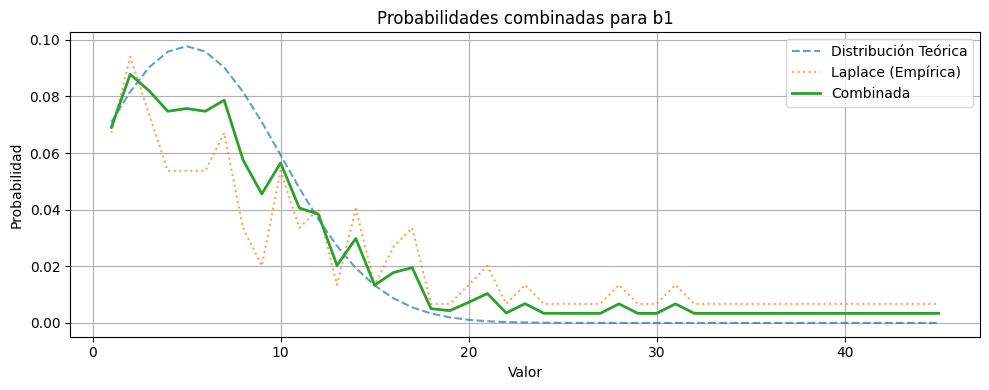

🎯 Siguientes valores más probables para b1:
  2: 0.0878
  3: 0.0820
  7: 0.0787
  5: 0.0757
  4: 0.0747
  6: 0.0747
  1: 0.0690
  8: 0.0576
  10: 0.0565
  9: 0.0456


In [25]:
b1_vals = next_gen_analyze("b1", body_size=104)

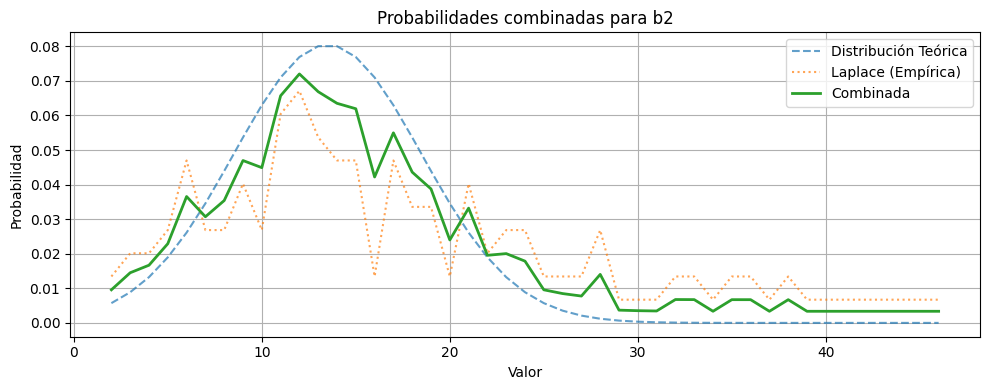

🎯 Siguientes valores más probables para b2:
  12: 0.0720
  13: 0.0669
  11: 0.0657
  14: 0.0635
  15: 0.0619
  17: 0.0550
  9: 0.0470
  10: 0.0449
  18: 0.0436
  16: 0.0422


In [26]:
b2_vals = next_gen_analyze("b2", body_size=104)

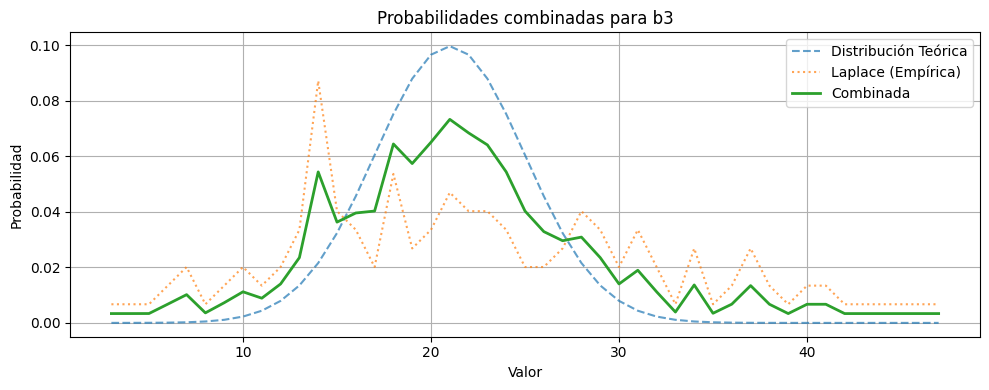

🎯 Siguientes valores más probables para b3:
  21: 0.0734
  22: 0.0685
  20: 0.0651
  18: 0.0645
  23: 0.0641
  19: 0.0574
  24: 0.0544
  14: 0.0544
  17: 0.0403
  25: 0.0403


In [27]:
b3_vals = next_gen_analyze("b3", body_size=104)

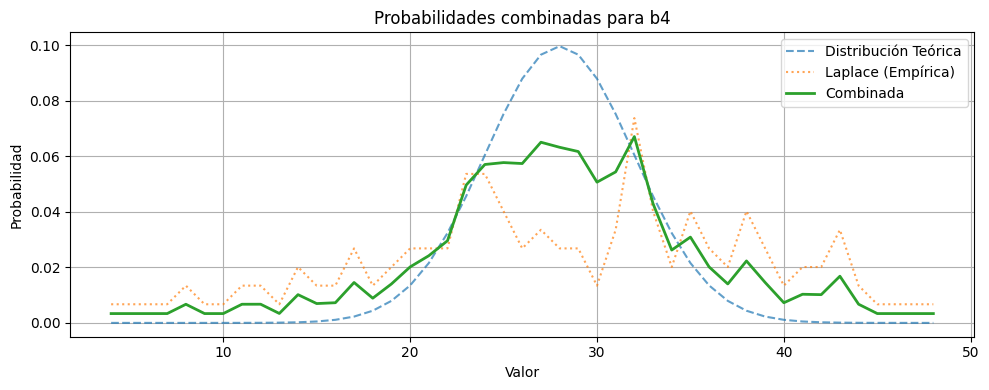

🎯 Siguientes valores más probables para b4:
  32: 0.0672
  27: 0.0651
  28: 0.0633
  29: 0.0618
  25: 0.0578
  26: 0.0574
  24: 0.0571
  31: 0.0544
  30: 0.0507
  23: 0.0497


In [28]:
b4_vals = next_gen_analyze("b4", body_size=104)

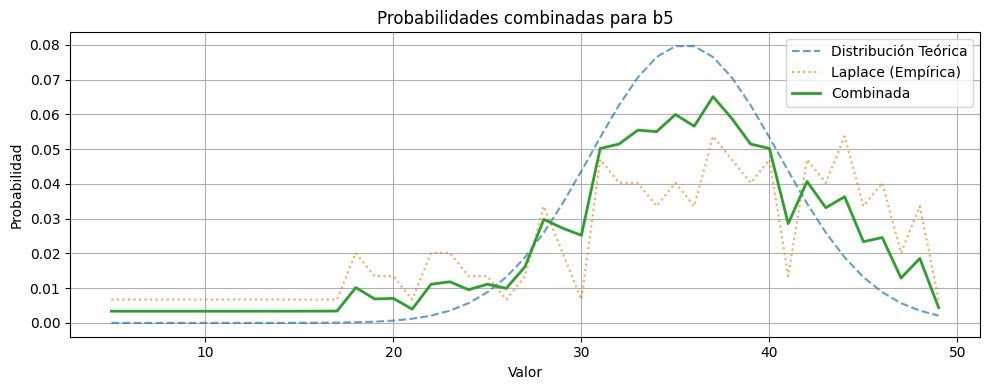

🎯 Siguientes valores más probables para b5:
  37: 0.0651
  35: 0.0599
  38: 0.0588
  36: 0.0566
  33: 0.0554
  34: 0.0550
  32: 0.0514
  39: 0.0514
  31: 0.0502
  40: 0.0502


In [29]:
b5_vals = next_gen_analyze("b5", body_size=104)

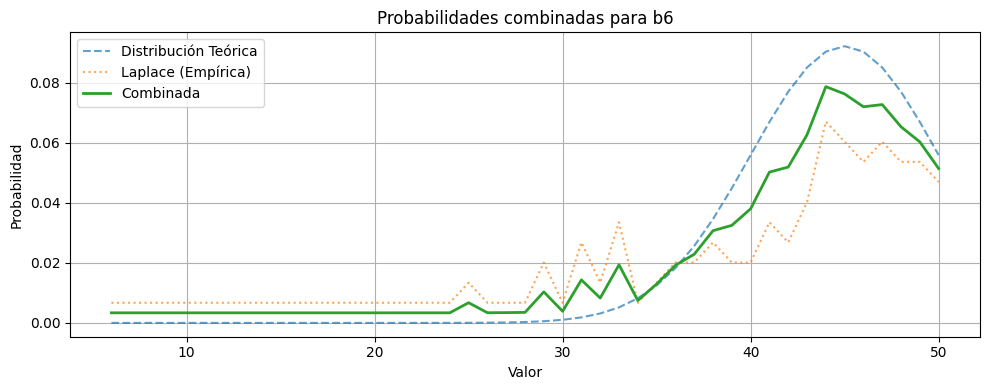

🎯 Siguientes valores más probables para b6:
  44: 0.0788
  45: 0.0763
  47: 0.0728
  46: 0.0721
  48: 0.0654
  43: 0.0627
  49: 0.0603
  42: 0.0520
  50: 0.0515
  41: 0.0503


In [30]:
b6_vals = next_gen_analyze("b6", body_size=104)